# Transfer Learning with TensorFlow - Scaling up ⚓

We've seen the power of transfer learning feature extraction and fine-tuning, now it's time to scale up to all of the classes in Food101 (101 total classes of food).  

Our goal is to beat the original Food101 paper with 10% of the training (leveraging th power of deep learning).  

https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/static/bossard_eccv14_food-101.pdf  

⚓------------------------------------------------ ⚓

Our baseline to beat is 50.76 ½ accuracy across 101 classes.  



In [21]:
!nvidia-smi

Thu May 28 18:54:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   75C    P0             33W /   70W |     107MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Creating helper functions

In [22]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py


--2026-05-28 18:54:57--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py.1’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-05-28 18:54:57 (98.8 MB/s) - ‘helper_functions.py.1’ saved [10246/10246]



In [23]:
from helper_functions import create_tensorboard_callback, plot_loss_curves, compare_historys, unzip_data, walk_through_dir

## 101 Food Classes : working with less data

Our goal is to beat the original Food101 paper with 10& of the training data, so let'S download it.  

The data we're downloading comes from the original Food101 dataset but has been preprocessed using the image_data_modification notebook.Link is here:  

https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/image_data_modification.ipynb  



In [24]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip

--2026-05-28 18:54:57--  https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 172.253.154.207, 142.250.153.207, 142.250.145.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.253.154.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1625420029 (1.5G) [application/zip]
Saving to: ‘101_food_classes_10_percent.zip.1’

101_food_classes_10 100%[===================>]   1.51G  40.9MB/s    in 40s     

2026-05-28 18:55:38 (38.4 MB/s) - ‘101_food_classes_10_percent.zip.1’ saved [1625420029/1625420029]



In [25]:
unzip_data("101_food_classes_10_percent.zip")

In [26]:
train_dir = "101_food_classes_10_percent/train/"
test_dir = "101_food_classes_10_percent/test/"

In [27]:
# How many images/classes are there?
walk_through_dir("101_food_classes_10_percent")

There are 2 directories and 0 images in '101_food_classes_10_percent'.
There are 101 directories and 0 images in '101_food_classes_10_percent/train'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/scallops'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/escargots'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/strawberry_shortcake'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/carrot_cake'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/hot_and_sour_soup'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/falafel'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/donuts'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/filet_mignon'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/french_fries'.
There are 0 directories and 75 images

In [28]:
# Setup data inputs
import tensorflow as tf
IMG_SIZE = (224, 224)

In [29]:
train_data_all_10_percent = tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                                label_mode="categorical",
                                                                                image_size=IMG_SIZE)

test_data_all_10_percent = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                                label_mode="categorical",
                                                                                image_size=IMG_SIZE,
                                                                                shuffle=False) #default = True


Found 7575 files belonging to 101 classes.
Found 25250 files belonging to 101 classes.


## Train a big dog model with transfer learning on 10% of 101 food classes  

Here are the steps we're goimg to take:  
* Create a ModelCheckpoint callback
* Create a data augmentation layer to right into the model  
* Build a headless (no top layers) Functional EfficientNetB0 backbone-model (we'll create our own output layer)  
* Compile our model  
* Feature extract for 5 full passes (5 epochs on the train dataset and validation on %15 of the test data to save epoch time).  


In [30]:
# Create checkpoint callback
checkpoint_path = "data_model_checkpoint_101_classes_10_percent.weights.h5"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                         save_weights_only=True,
                                                         monitor="val_accuracy",
                                                         save_best_only=True)

In [31]:
# Create data augmentation layer
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [32]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2),
    layers.RandomZoom(0.2),
    #layers.Rescaling(1/255) # rescale doesn't need in Efficientet
], name="data_augmentation")


In [33]:
# Setup the base model and freeze its layers (whis will extract features)
base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False

# Setup model architecture with trainable top layers
inputs = layers.Input(shape=(224, 224, 3), name="input_layer")
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
outputs = layers.Dense(len(train_data_all_10_percent.class_names), activation="softmax", name="output_layer")(x)
model = tf.keras.Model(inputs, outputs)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [34]:
# Summary
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 101)            │       129,381 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,178,952 (15.94 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [35]:
# Compile
model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=["accuracy"])
# Fit
history_all_classes_10_percent = model.fit(train_data_all_10_percent,
                                          epochs=5,
                                          steps_per_epoch=len(train_data_all_10_percent),
                                          validation_data=test_data_all_10_percent,
                                           validation_steps=int(0.15 * len(test_data_all_10_percent)),
                                          callbacks=[checkpoint_callback])


Epoch 1/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 60s 188ms/step - accuracy: 0.2619 - loss: 3.4383 - val_accuracy: 0.4314 - val_loss: 2.5993
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 40s 170ms/step - accuracy: 0.4758 - loss: 2.2636 - val_accuracy: 0.4897 - val_loss: 2.1514
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 40s 167ms/step - accuracy: 0.5456 - loss: 1.9108 - val_accuracy: 0.5350 - val_loss: 1.8876
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 40s 166ms/step - accuracy: 0.5889 - loss: 1.6904 - val_accuracy: 0.5387 - val_loss: 1.8257
Epoch 5/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 40s 168ms/step - accuracy: 0.6203 - loss: 1.5475 - val_accuracy: 0.5466 - val_loss: 1.7636


In [36]:
# Evaluate on the whole test dataset
feature_extraction_results = model.evaluate(test_data_all_10_percent)
feature_extraction_results

790/790 ━━━━━━━━━━━━━━━━━━━━ 65s 82ms/step - accuracy: 0.5866 - loss: 1.5846


[1.584570050239563, 0.5865742564201355]

In [37]:
from helper_functions import plot_loss_curves

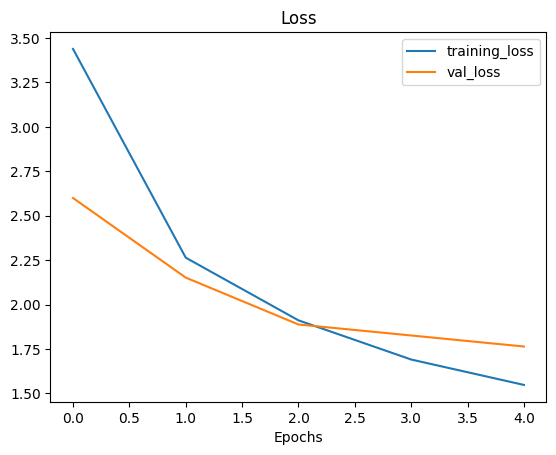

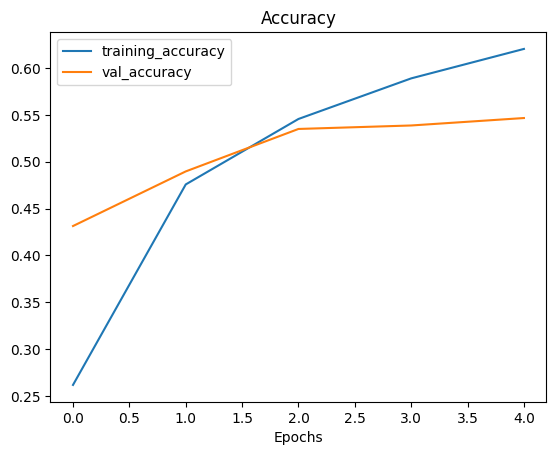

In [38]:
plot_loss_curves(history_all_classes_10_percent)

⚓ **Question:** What do these curves suggest?  

Hint:  Ideally, the two curves should be very similar to each other.

## Fine-tuning

In [39]:
# Unfreeze all of the layers in the base model
base_model.trainable = True

#Refreeze every layer except some top layers we decide
for layer in base_model.layers[:-5]:
  layer.trainable = False


In [40]:
# Recompile model with lower learning rate
model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              metrics=["accuracy"])


In [41]:
# What layers in the model trainable
for layer in model.layers:
  print(layer.name, layer.trainable)

input_layer True
data_augmentation True
efficientnetb0 True
global_average_pooling_layer True
output_layer True


In [42]:
# Trainable status in our base model
for layer_number, layer in enumerate(model.layers[2].layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer False
1 rescaling False
2 normalization False
3 rescaling_1 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeeze Fals

In [43]:
# Create another checkpoint callback
checkpoint_path_fine_tune = "data_model_checkpoint_101_classes_10_percent_fine_tune.weights.h5"
checkpoint_callback_fine_tune = tf.keras.callbacks.ModelCheckpoint(checkpoint_path_fine_tune,
                                                         save_weights_only=True,
                                                         monitor="val_accuracy",
                                                         save_best_only=True)

In [44]:
# Fine-tune for 5 more epochs
fine_tune_epochs = 10 # has already done 5 epochs (total epochs = 10 = 5 + 5)

# Fine-tune our model
history_all_classes_10_percent_fine_tune = model.fit(train_data_all_10_percent,
                                                     epochs=fine_tune_epochs,
                                                     steps_per_epoch=len(train_data_all_10_percent),
                                                     validation_data=test_data_all_10_percent,
                                                     validation_steps=int(0.15 * len(test_data_all_10_percent)),
                                                     initial_epoch=history_all_classes_10_percent.epoch[-1]+1,
                                                     callbacks=[checkpoint_callback_fine_tune])


Epoch 6/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 56s 181ms/step - accuracy: 0.6422 - loss: 1.4669 - val_accuracy: 0.5718 - val_loss: 1.6610
Epoch 7/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 77s 165ms/step - accuracy: 0.6675 - loss: 1.3223 - val_accuracy: 0.5752 - val_loss: 1.6233
Epoch 8/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 40s 167ms/step - accuracy: 0.6896 - loss: 1.2440 - val_accuracy: 0.5824 - val_loss: 1.6049
Epoch 9/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 40s 169ms/step - accuracy: 0.7080 - loss: 1.1750 - val_accuracy: 0.5855 - val_loss: 1.5772
Epoch 10/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 40s 164ms/step - accuracy: 0.7281 - loss: 1.1043 - val_accuracy: 0.5779 - val_loss: 1.5885


In [45]:
history_all_classes_10_percent_fine_tune_results = model.evaluate(test_data_all_10_percent)
history_all_classes_10_percent_fine_tune_results

790/790 ━━━━━━━━━━━━━━━━━━━━ 63s 80ms/step - accuracy: 0.6205 - loss: 1.4158


[1.4157840013504028, 0.6204752326011658]

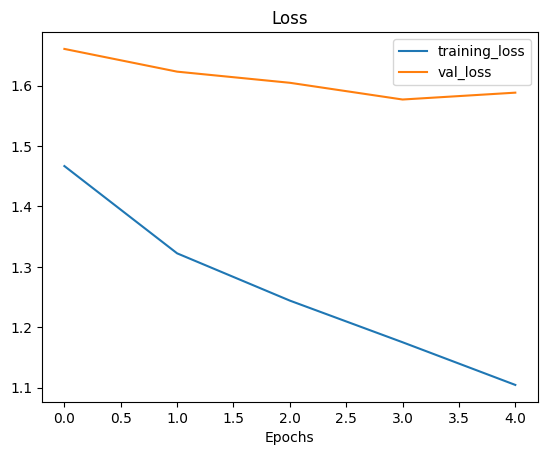

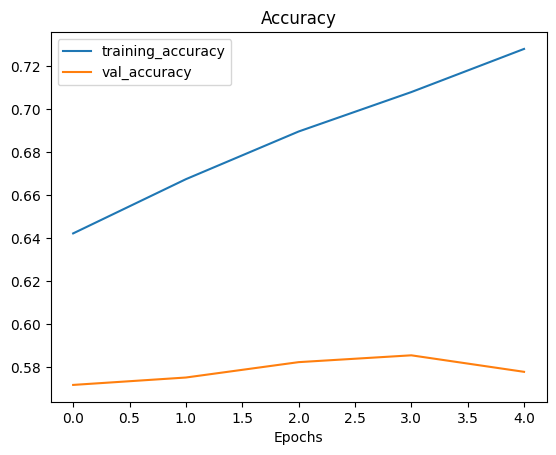

In [46]:
plot_loss_curves(history_all_classes_10_percent_fine_tune)

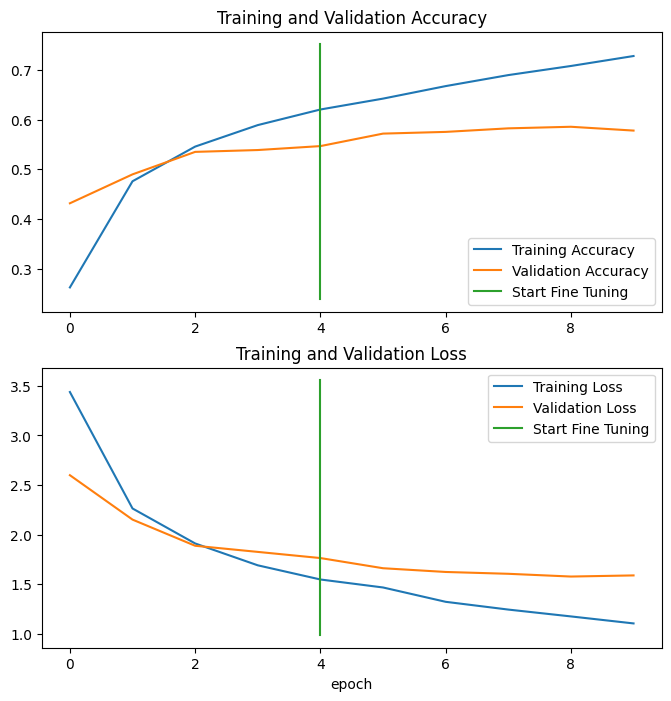

In [47]:
# Compare the histories of feature extraction model with fine-tuning model
compare_historys(history_all_classes_10_percent, history_all_classes_10_percent_fine_tune)

## Sving and loading our model  

To use our model in an exertal application, we'll need to save and export.  


In [48]:
# Save our fine-tuned model
model.save("/content/drive/MyDrive/Deep Learning/101_food_classes_10_percent_fine_tuned_model.keras")

In [49]:
# Load and evaluate saved model
loaded_model = tf.keras.models.load_model("/content/drive/MyDrive/Deep Learning/101_food_classes_10_percent_fine_tuned_model.keras")
loaded_model.evaluate(test_data_all_10_percent)

790/790 ━━━━━━━━━━━━━━━━━━━━ 69s 81ms/step - accuracy: 0.6205 - loss: 1.4158


[1.4157840013504028, 0.6204752326011658]

In [50]:
history_all_classes_10_percent_fine_tune_results, loaded_model.evaluate(test_data_all_10_percent)

790/790 ━━━━━━━━━━━━━━━━━━━━ 64s 81ms/step - accuracy: 0.6205 - loss: 1.4158


([1.4157840013504028, 0.6204752326011658],
 [1.4157840013504028, 0.6204752326011658])

## Evaluating the performance of our model across all differernt classes  

Let's make some predictions, visualize them and later find out which predictions were the "most wrong.  


In [51]:
loaded_model_result = loaded_model.evaluate(test_data_all_10_percent)
loaded_model_result

790/790 ━━━━━━━━━━━━━━━━━━━━ 64s 81ms/step - accuracy: 0.6205 - loss: 1.4158


[1.4157840013504028, 0.6204752326011658]

In [52]:
loaded_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 101)            │       129,381 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,000,596 (22.89 MB)

 Trainable params: 910,821 (3.47 MB)

 Non-trainable params: 3,268,131 (12.47 MB)

 Optimizer params: 1,821,644 (6.95 MB)

In [53]:
# Make predictions with model
preds_probs = loaded_model.predict(test_data_all_10_percent, verbose=1)

790/790 ━━━━━━━━━━━━━━━━━━━━ 69s 83ms/step


In [54]:
len(test_data_all_10_percent)

790

In [55]:
790 * 32

25280

In [56]:
len(preds_probs)

25250

In [57]:
preds_probs.shape

(25250, 101)

In [58]:
# Let's see what the first 10 predictions look like
preds_probs[:10]

array([[1.9883999e-01, 2.7414830e-04, 2.7419564e-01, ..., 1.1267129e-04,
        3.3576365e-03, 1.5344488e-02],
       [9.4867247e-01, 3.0369688e-07, 8.9523598e-04, ..., 1.3377654e-03,
        1.8894834e-06, 2.3897603e-05],
       [4.4480190e-01, 1.0544457e-02, 1.8966859e-02, ..., 1.4900425e-03,
        8.8948838e-04, 5.6263255e-03],
       ...,
       [1.1513208e-01, 5.1272051e-05, 2.8487572e-03, ..., 1.5604128e-01,
        1.0945488e-03, 5.6194462e-04],
       [1.6037858e-01, 3.3296918e-04, 3.1560946e-01, ..., 5.3610763e-04,
        2.7552305e-04, 4.8574674e-04],
       [6.4403492e-01, 4.6073096e-06, 2.6490339e-03, ..., 2.8245247e-03,
        1.0826626e-05, 9.6135313e-04]], dtype=float32)

In [59]:
# What does the first prediction probability array look like?
preds_probs[0], len(preds_probs[0]), sum(preds_probs[0])

(array([1.98839992e-01, 2.74148304e-04, 2.74195641e-01, 4.32927027e-06,
        1.30472581e-05, 1.23798800e-05, 3.01432738e-04, 2.59489298e-05,
        2.38984562e-02, 1.20528485e-03, 8.31342368e-06, 2.42325477e-05,
        2.53794645e-03, 2.53955523e-06, 7.34150410e-03, 1.39208126e-03,
        1.75071385e-04, 2.59307749e-03, 3.87514150e-03, 1.47272631e-05,
        1.18474418e-03, 2.66607094e-05, 4.98875859e-04, 4.82929347e-04,
        1.79347117e-03, 2.19937577e-03, 1.16222608e-03, 1.67835940e-04,
        1.15078464e-01, 1.07094296e-03, 8.51505229e-06, 1.51545752e-03,
        8.89559509e-04, 2.21186565e-05, 9.16425325e-03, 3.51884155e-05,
        3.91722861e-04, 2.06607394e-03, 2.25009527e-02, 2.34441279e-04,
        6.56219199e-04, 2.71140342e-03, 8.28728545e-04, 6.16746038e-05,
        5.15300548e-04, 1.00192759e-04, 2.63611251e-03, 7.35240392e-05,
        2.17717297e-05, 4.84107174e-02, 3.25399131e-04, 4.57940943e-04,
        9.22354162e-02, 1.99168473e-02, 2.82797788e-04, 1.359452

Our model outputs a prediction probability array (with N number of variables şs the number of classes) for each sample passed to the predict method.  


In [60]:
# We get one prediction probability per class (in our case there're 101 prediction probabilities)
print(f"Number of prediction probablities fro sample 0: {len(preds_probs[0])}")
print(f"What prediction probability sample 0 looks like:\n {preds_probs[0]}")
print(f"The class with the highest predicted probability by the model for sample 0: {preds_probs[0].argmax()}")

Number of prediction probablities fro sample 0: 101
What prediction probability sample 0 looks like:
 [1.98839992e-01 2.74148304e-04 2.74195641e-01 4.32927027e-06
 1.30472581e-05 1.23798800e-05 3.01432738e-04 2.59489298e-05
 2.38984562e-02 1.20528485e-03 8.31342368e-06 2.42325477e-05
 2.53794645e-03 2.53955523e-06 7.34150410e-03 1.39208126e-03
 1.75071385e-04 2.59307749e-03 3.87514150e-03 1.47272631e-05
 1.18474418e-03 2.66607094e-05 4.98875859e-04 4.82929347e-04
 1.79347117e-03 2.19937577e-03 1.16222608e-03 1.67835940e-04
 1.15078464e-01 1.07094296e-03 8.51505229e-06 1.51545752e-03
 8.89559509e-04 2.21186565e-05 9.16425325e-03 3.51884155e-05
 3.91722861e-04 2.06607394e-03 2.25009527e-02 2.34441279e-04
 6.56219199e-04 2.71140342e-03 8.28728545e-04 6.16746038e-05
 5.15300548e-04 1.00192759e-04 2.63611251e-03 7.35240392e-05
 2.17717297e-05 4.84107174e-02 3.25399131e-04 4.57940943e-04
 9.22354162e-02 1.99168473e-02 2.82797788e-04 1.35945249e-02
 2.36033797e-02 2.75236904e-03 8.18110164e-0

In [61]:
test_data_all_10_percent.class_names

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito',
 'bruschetta',
 'caesar_salad',
 'cannoli',
 'caprese_salad',
 'carrot_cake',
 'ceviche',
 'cheese_plate',
 'cheesecake',
 'chicken_curry',
 'chicken_quesadilla',
 'chicken_wings',
 'chocolate_cake',
 'chocolate_mousse',
 'churros',
 'clam_chowder',
 'club_sandwich',
 'crab_cakes',
 'creme_brulee',
 'croque_madame',
 'cup_cakes',
 'deviled_eggs',
 'donuts',
 'dumplings',
 'edamame',
 'eggs_benedict',
 'escargots',
 'falafel',
 'filet_mignon',
 'fish_and_chips',
 'foie_gras',
 'french_fries',
 'french_onion_soup',
 'french_toast',
 'fried_calamari',
 'fried_rice',
 'frozen_yogurt',
 'garlic_bread',
 'gnocchi',
 'greek_salad',
 'grilled_cheese_sandwich',
 'grilled_salmon',
 'guacamole',
 'gyoza',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'huevos_rancheros',
 'hummus',
 'ice_cream',
 'lasagna',
 'lobster_bisque',
 'lobster

In [62]:
# Get the pred classes of each label
pred_classes = preds_probs.argmax(axis=1)

# How do they look?
pred_classes[:10]

array([ 2,  0,  0, 38,  8, 78, 29, 46,  2,  0])

In [63]:
len(pred_classes)

25250

Now we've got a predictions array of all of our model's predictions, to evalute them, we need to compare them to the original test dataset labels.  


In [64]:
test_data_all_10_percent

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 101), dtype=tf.float32, name=None))>

In [65]:
# To get our test labels we need to unravel our test_data BatchDataset
test_labels = []
for images, labels in test_data_all_10_percent.unbatch():
  test_labels.append(labels.numpy().argmax())

test_labels[:10]

[np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0)]

We did shuffled=False before, so it looks like 0,0,0,0,0,.... in a order.  

We took true labels from the data.

In [66]:
# How many y_labels are there?
len(test_labels)

25250

## Evaluating our model's predcitions  

One way to check that our model's predictions array is in the same as our test labels array is to find the accuracy score.  



In [67]:
# Let's try scikit-learn's accuracy score function and see what it comes up with
from sklearn.metrics import accuracy_score

In [68]:
sklearn_accuracy = accuracy_score(y_true=test_labels,
                                  y_pred=pred_classes)
sklearn_accuracy

0.6204752475247525

In [69]:
# Does this metric come close to our model's evaluate results
import numpy as np
np.isclose(history_all_classes_10_percent_fine_tune_results[1], sklearn_accuracy)

np.True_

In [70]:
np.isclose(loaded_model_result[1], sklearn_accuracy)

np.True_

## Let's get visual:  making a confusion matrix

In [71]:
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(10, 10), text_size=15, norm=False, savefig=False):
  """Makes a labelled confusion matrix comparing predictions and ground truth labels.

  If classes is passed, confusion matrix will be labelled, if not, integer class values
  will be used.

  Args:
    y_true: Array of truth labels (must be same shape as y_pred).
    y_pred: Array of predicted labels (must be same shape as y_true).
    classes: Array of class labels (e.g. string form). If `None`, integer labels are used.
    figsize: Size of output figure (default=(10, 10)).
    text_size: Size of output figure text (default=15).
    norm: normalize values or not (default=False).
    savefig: save confusion matrix to file (default=False).

  Returns:
    A labelled confusion matrix plot comparing y_true and y_pred.

  Example usage:
    make_confusion_matrix(y_true=test_labels, # ground truth test labels
                          y_pred=y_preds, # predicted labels
                          classes=class_names, # array of class label names
                          figsize=(15, 15),
                          text_size=10)
  """
  # Create the confustion matrix
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize it
  n_classes = cm.shape[0] # find the number of classes we're dealing with

  # Plot the figure and make it pretty
  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.Blues) # colors will represent how 'correct' a class is, darker == better
  fig.colorbar(cax)

  # Are there a list of classes?
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  # Label the axes
  ax.set(title="Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes), # create enough axis slots for each class
         yticks=np.arange(n_classes),
         xticklabels=labels, # axes will labeled with class names (if they exist) or ints
         yticklabels=labels)

  # Make x-axis labels appear on bottom
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  ## Changed (plot x-labels veritcally)
  plt.xticks(rotation=70, fontsize=text_size)
  plt.yticks(fontsize=text_size)

  # Set the threshold for different colors
  threshold = (cm.max() + cm.min()) / 2.

  # Plot the text on each cell
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    if norm:
      plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)
    else:
      plt.text(j, i, f"{cm[i, j]}",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)

  # Save the figure to the current working directory
  if savefig:
    fig.savefig("confusion_matrix.png")

In [72]:
class_names = test_data_all_10_percent.class_names

In [73]:
make_confusion_matrix(y_true=test_labels,
                      y_pred=pred_classes,
                      classes=class_names,
                      figsize=(100, 100),
                      text_size=20,
                      savefig=True)

## Let's keep the evaluation train going, time for a classification report

Scikit-learn has a helpful function for acquiring many different classification metrics per class  (e.g. precision, recall and F1).  

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html


In [74]:
from sklearn.metrics import classification_report

In [75]:
print(classification_report(y_true=test_labels,
                            y_pred=pred_classes,
                            target_names=class_names))


                         precision    recall  f1-score   support

              apple_pie       0.32      0.20      0.25       250
         baby_back_ribs       0.62      0.68      0.65       250
                baklava       0.60      0.69      0.65       250
         beef_carpaccio       0.74      0.56      0.64       250
           beef_tartare       0.58      0.44      0.50       250
             beet_salad       0.47      0.41      0.44       250
               beignets       0.76      0.78      0.77       250
               bibimbap       0.84      0.80      0.82       250
          bread_pudding       0.28      0.56      0.38       250
      breakfast_burrito       0.43      0.68      0.53       250
             bruschetta       0.53      0.42      0.47       250
           caesar_salad       0.76      0.62      0.69       250
                cannoli       0.72      0.63      0.67       250
          caprese_salad       0.53      0.60      0.56       250
            carrot_cake 

The numbers above give a great class-by-class evaluation of our model's predictions but with so many classes, they're quite hard to understand.  

How about we create a visualization to get better understanding?

In [76]:
classification_report_dict = classification_report(y_true=test_labels,
                                                   y_pred=pred_classes,
                                                   target_names=class_names,
                                                   output_dict=True)
classification_report_dict

{'apple_pie': {'precision': 0.31645569620253167,
  'recall': 0.2,
  'f1-score': 0.24509803921568626,
  'support': 250.0},
 'baby_back_ribs': {'precision': 0.6204379562043796,
  'recall': 0.68,
  'f1-score': 0.648854961832061,
  'support': 250.0},
 'baklava': {'precision': 0.6048951048951049,
  'recall': 0.692,
  'f1-score': 0.6455223880597015,
  'support': 250.0},
 'beef_carpaccio': {'precision': 0.7407407407407407,
  'recall': 0.56,
  'f1-score': 0.6378132118451025,
  'support': 250.0},
 'beef_tartare': {'precision': 0.5759162303664922,
  'recall': 0.44,
  'f1-score': 0.4988662131519274,
  'support': 250.0},
 'beet_salad': {'precision': 0.4703196347031963,
  'recall': 0.412,
  'f1-score': 0.43923240938166314,
  'support': 250.0},
 'beignets': {'precision': 0.7587548638132295,
  'recall': 0.78,
  'f1-score': 0.7692307692307693,
  'support': 250.0},
 'bibimbap': {'precision': 0.8403361344537815,
  'recall': 0.8,
  'f1-score': 0.819672131147541,
  'support': 250.0},
 'bread_pudding': {'p

Let's plot all of our classes F1-scores

In [77]:
# Create empty dictionary
class_f1_scores = {}

for k, v in classification_report_dict.items():
    if k in ["accuracy", "macro avg", "weighted avg"]:
        continue
    else:
        class_f1_scores[k] = v["f1-score"]

class_f1_scores

{'apple_pie': 0.24509803921568626,
 'baby_back_ribs': 0.648854961832061,
 'baklava': 0.6455223880597015,
 'beef_carpaccio': 0.6378132118451025,
 'beef_tartare': 0.4988662131519274,
 'beet_salad': 0.43923240938166314,
 'beignets': 0.7692307692307693,
 'bibimbap': 0.819672131147541,
 'bread_pudding': 0.37751004016064255,
 'breakfast_burrito': 0.5256609642301711,
 'bruschetta': 0.46741573033707867,
 'caesar_salad': 0.6872246696035242,
 'cannoli': 0.6723404255319149,
 'caprese_salad': 0.5639097744360902,
 'carrot_cake': 0.5795454545454546,
 'ceviche': 0.41749502982107356,
 'cheese_plate': 0.6157112526539278,
 'cheesecake': 0.4570383912248629,
 'chicken_curry': 0.5232558139534884,
 'chicken_quesadilla': 0.6652360515021459,
 'chicken_wings': 0.7158273381294964,
 'chocolate_cake': 0.569593147751606,
 'chocolate_mousse': 0.3655030800821355,
 'churros': 0.7600849256900213,
 'clam_chowder': 0.7450980392156863,
 'club_sandwich': 0.7016129032258065,
 'crab_cakes': 0.4098671726755218,
 'creme_brule

In [78]:
# Turn f1-scores into dataframe for visualization
import pandas as pd
f1_scores = pd.DataFrame({"class_names": list(class_f1_scores.keys()),
                         "f1-score": list(class_f1_scores.values())}).sort_values("f1-score", ascending=False)
f1_scores

,class_names,f1-score
33,edamame,0.974257
63,macarons,0.888412
86,sashimi,0.850299
65,mussels,0.843882
69,oysters,0.839104
...,...,...
56,huevos_rancheros,0.359431
77,pork_chop,0.343313
39,foie_gras,0.334247
82,ravioli,0.306723


In [79]:
f1_scores[:10]

,class_names,f1-score
33,edamame,0.974257
63,macarons,0.888412
86,sashimi,0.850299
65,mussels,0.843882
69,oysters,0.839104
75,pho,0.839080
45,frozen_yogurt,0.836439
32,dumplings,0.835644
54,hot_and_sour_soup,0.833333
68,onion_rings,0.826613


In [80]:
f1_scores[-10:]

,class_names,f1-score
50,grilled_salmon,0.409326
99,tuna_tartare,0.406312
8,bread_pudding,0.377510
93,steak,0.375286
22,chocolate_mousse,0.365503
56,huevos_rancheros,0.359431
77,pork_chop,0.343313
39,foie_gras,0.334247
82,ravioli,0.306723
0,apple_pie,0.245098


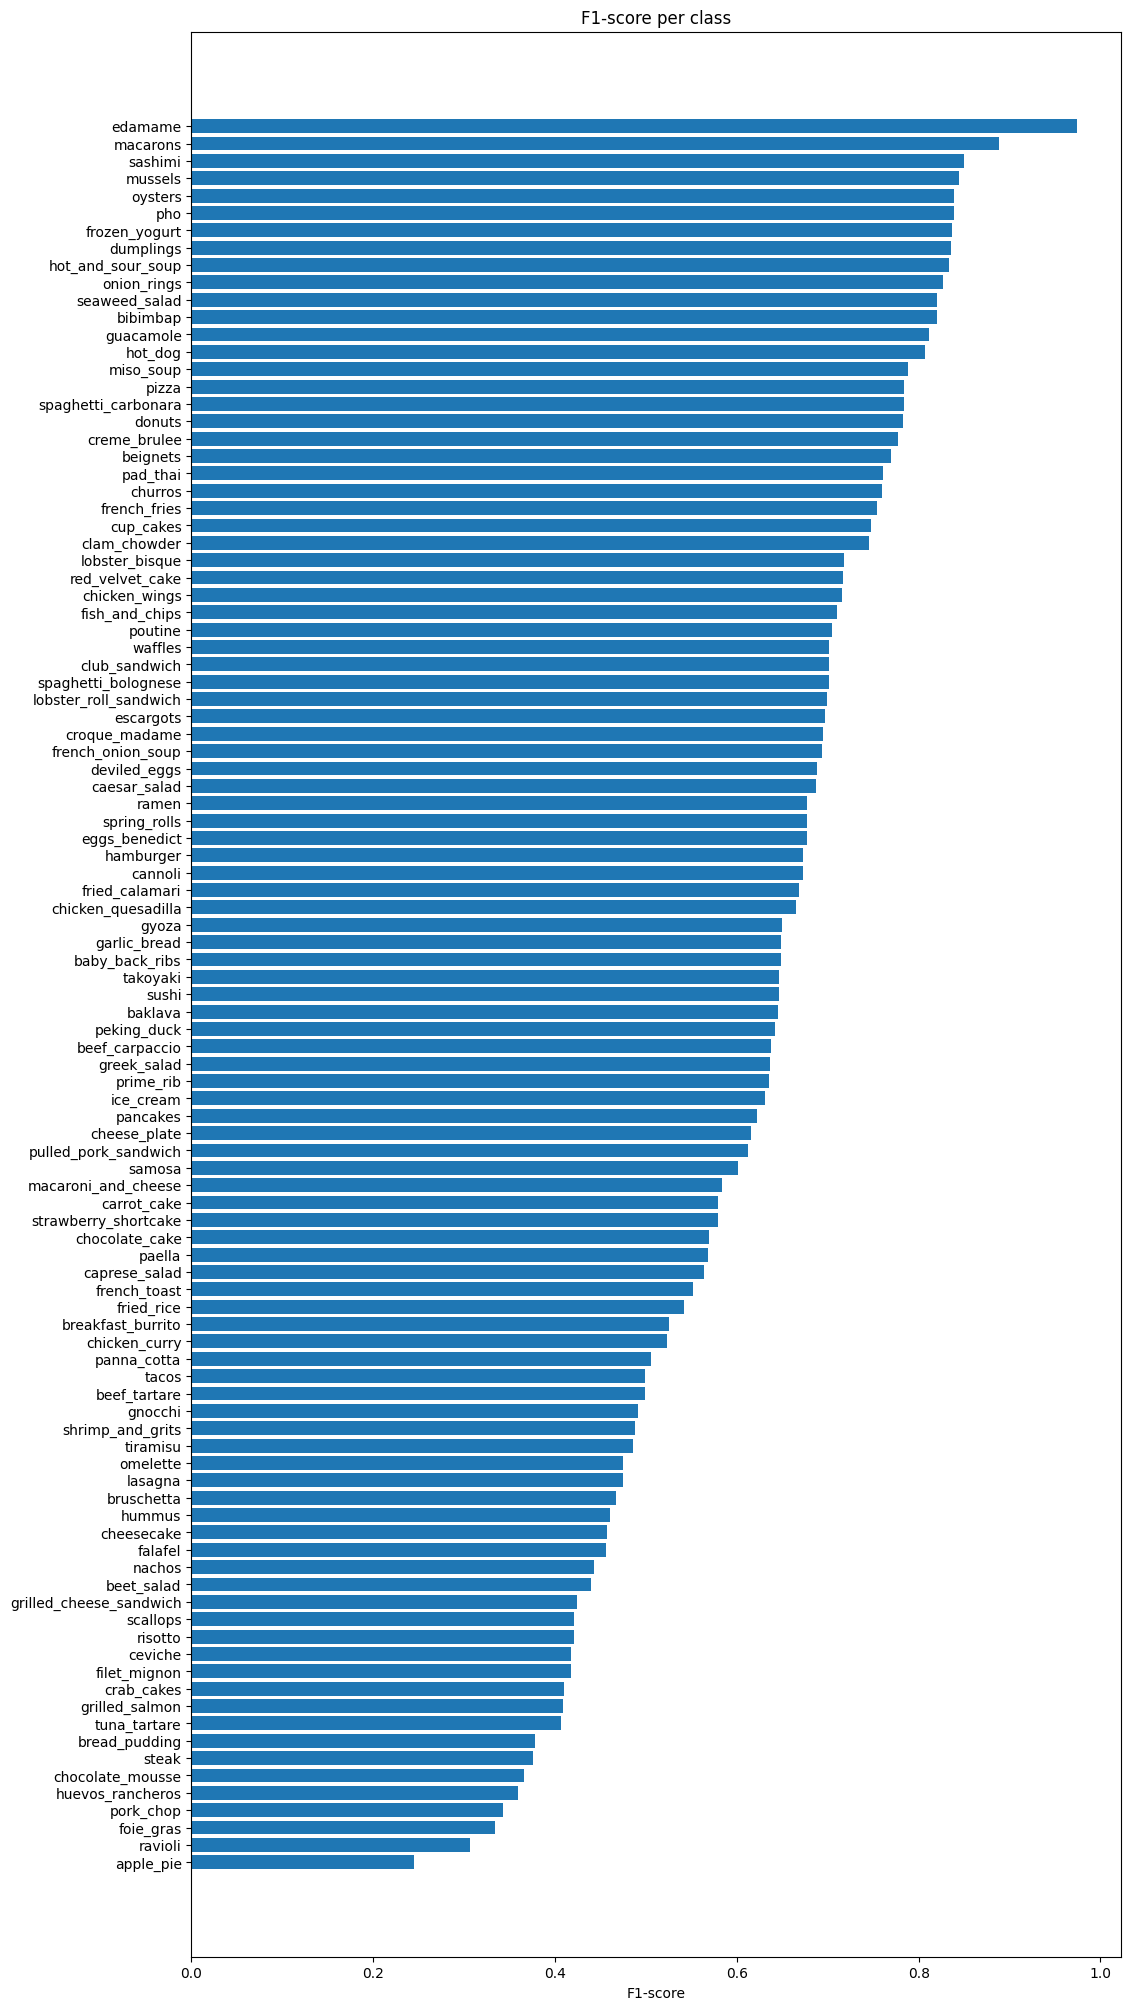

In [81]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 25))
scores = ax.barh(range(len(f1_scores)), f1_scores["f1-score"].values)
ax.set_yticks(range(len(f1_scores)))
ax.set_yticklabels(f1_scores["class_names"])
ax.set_xlabel("F1-score")
ax.set_title("F1-score per class")
ax.invert_yaxis()

If people take photos of apple-pie, ravoli etc. our model possibly predict wrong.  

How are we gonna fix this?  


In [82]:
worst_10_classes = f1_scores.sort_values("f1-score", ascending=True).head(10)

worst_10_classes

,class_names,f1-score
0,apple_pie,0.245098
82,ravioli,0.306723
39,foie_gras,0.334247
77,pork_chop,0.343313
56,huevos_rancheros,0.359431
22,chocolate_mousse,0.365503
93,steak,0.375286
8,bread_pudding,0.377510
99,tuna_tartare,0.406312
50,grilled_salmon,0.409326


## Visualizing predictions on custom images  

Now, this is the real test, how does our model go on food images not even in pur test dataset (images of our own).  

- Read in a target image filepath using `tf.io.read_file()`  
* Turn the image into a Tensor using ``tf.io.decode_image()`  
* Resize the image tensor to be the same size as the images our model has trained on using to be the same as the images our model has trained on using `tf.image.resize()`  
* Scale the image to get all of the pixel values between 0 and 1 (if necessary).  


In [84]:
import tensorflow as tf

def load_and_prep_image(filename, img_shape=224, scale=True):
    # Read image file
    img = tf.io.read_file(filename)

    # Decode image
    img = tf.image.decode_image(img, channels=3)

    # Resize image
    img = tf.image.resize(img, size=[img_shape, img_shape])

    # Scale if needed
    if scale:
        img = img / 255.

    return img

Now, we've got a function to load and prepare target images, let's now write some code to visualize images, their target label and our model's predictions.  

Specifically, we'll write some code to :  

1. Load a few random images from the test dataaset.  
2. Make predictions on the loaded images.  
3. Plot the original image(s) along with model's predictions, prediction probability and truth label.  

In [85]:
random.choice(class_names)

'beef_tartare'

In [86]:
test_dir

'101_food_classes_10_percent/test/'

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


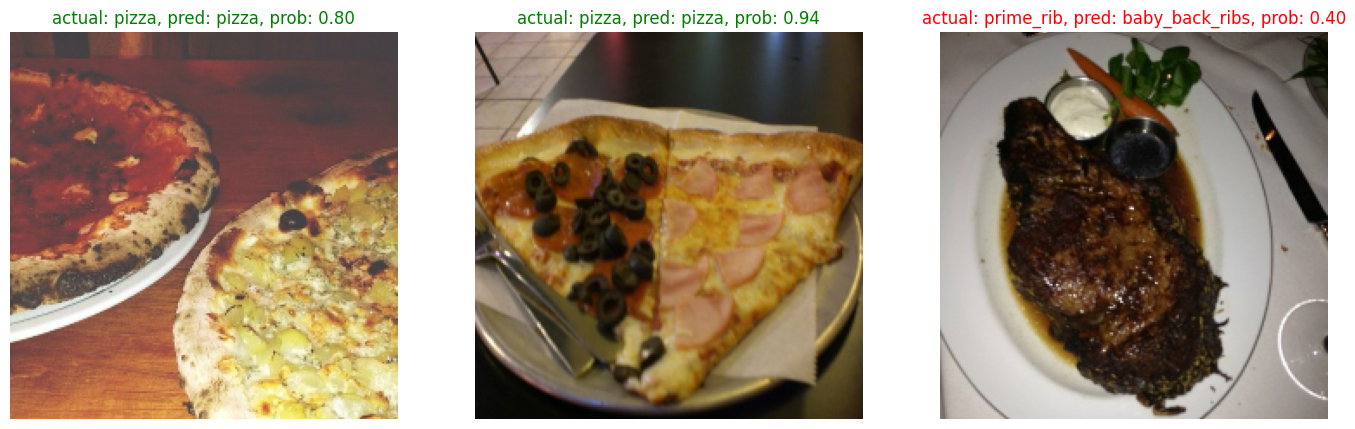

In [87]:
plt.figure(figsize=(17, 10))
for i in range(3):
  # Choose a random image from  a random class
  class_name = random.choice(class_names)
  filename = random.choice(os.listdir(test_dir + "/" + class_name))
  filepath = test_dir + "/" + class_name + "/" + filename

  # Load the image
  img = load_and_prep_image(filepath, scale=False)

  # Make predictions
  img_expanded = tf.expand_dims(img, axis=0)
  #print(img_expanded)
  pred_prob = loaded_model.predict(img_expanded) # prediction probability array
  pred_class = class_names[np.argmax(pred_prob)] # get highest prediction probability index
  #print(pred_prob)
  #print(pred_class)

  # Plot the images
  plt.subplot(1, 3, i + 1)
  plt.imshow(img/255.)
  if class_name == pred_class:
    title_color="g"
  else:
     title_color="r"
  plt.title(f"actual: {class_name}, pred: {pred_class}, prob: {pred_prob.max():.2f}", c=title_color)
  plt.axis(False);

In [88]:
filepath

'101_food_classes_10_percent/test//prime_rib/3025684.jpg'

## Finding the most worng predictions

To find out where our model is most wrong, let's write some code to find out the following:  

1. Get all of the image file paths in the test dataset using [`list_files()`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset) method  
2. Create a pandas DataFrame of the image filepaths, ground truth labels, predicted classses (from our model), max prediction probabilities, prediciton class names, ground truth class names.   
3. Use our DataFrame to find all the wrong predictions (where the ground truth label doesn't match the prediction).  
4. Sort the DataFrame based on wrong predcitions (have the highest prediction probability predictions at the top).  
5. Visualize the images with the highest prediciton probabilities but have the wrong prediciton.  


In [89]:
# Get all of the image file paths in the test dataset
filepaths = []
for filepath in test_data_all_10_percent.list_files("/content/101_food_classes_10_percent/test/*/*.jpg",
                                                    shuffle=False):
  filepaths.append(filepath.numpy())
filepaths[:10]


[b'/content/101_food_classes_10_percent/test/apple_pie/1011328.jpg',
 b'/content/101_food_classes_10_percent/test/apple_pie/101251.jpg',
 b'/content/101_food_classes_10_percent/test/apple_pie/1034399.jpg',
 b'/content/101_food_classes_10_percent/test/apple_pie/103801.jpg',
 b'/content/101_food_classes_10_percent/test/apple_pie/1038694.jpg',
 b'/content/101_food_classes_10_percent/test/apple_pie/1047447.jpg',
 b'/content/101_food_classes_10_percent/test/apple_pie/1068632.jpg',
 b'/content/101_food_classes_10_percent/test/apple_pie/110043.jpg',
 b'/content/101_food_classes_10_percent/test/apple_pie/1106961.jpg',
 b'/content/101_food_classes_10_percent/test/apple_pie/1113017.jpg']

In [96]:
# Create a DataFrame of different parameters for each of out test images
import pandas as pd
pred_df = pd.DataFrame({"img_path": filepaths,
                        "y_true": test_labels,
                        "y_pred": pred_classes,
                       "pred_conf": preds_probs.max(axis=1),
                       "pred_class": pred_classes,
                       "true_class_name": [class_names[i] for i in test_labels],
                        "pred_class_name": [class_names[i] for i in pred_classes]})
pred_df


,img_path,y_true,y_pred,pred_conf,pred_class,true_class_name,pred_class_name
0,b'/content/101_food_classes_10_percent/test/ap...,0,2,0.274196,2,apple_pie,baklava
1,b'/content/101_food_classes_10_percent/test/ap...,0,0,0.948672,0,apple_pie,apple_pie
2,b'/content/101_food_classes_10_percent/test/ap...,0,0,0.444802,0,apple_pie,apple_pie
3,b'/content/101_food_classes_10_percent/test/ap...,0,38,0.242995,38,apple_pie,fish_and_chips
4,b'/content/101_food_classes_10_percent/test/ap...,0,8,0.413529,8,apple_pie,bread_pudding
...,...,...,...,...,...,...,...
25245,b'/content/101_food_classes_10_percent/test/wa...,100,100,0.971007,100,waffles,waffles
25246,b'/content/101_food_classes_10_percent/test/wa...,100,100,0.623628,100,waffles,waffles
25247,b'/content/101_food_classes_10_percent/test/wa...,100,100,0.281466,100,waffles,waffles
25248,b'/content/101_food_classes_10_percent/test/wa...,100,100,0.253910,100,waffles,waffles


In [97]:
# Find out in our DataFrame which predictions are wrong
pred_df["pred_correct"] = pred_df["y_true"] == pred_df["y_pred"]
pred_df.head()

,img_path,y_true,y_pred,pred_conf,pred_class,true_class_name,pred_class_name,pred_correct
0,b'/content/101_food_classes_10_percent/test/ap...,0,2,0.274196,2,apple_pie,baklava,False
1,b'/content/101_food_classes_10_percent/test/ap...,0,0,0.948672,0,apple_pie,apple_pie,True
2,b'/content/101_food_classes_10_percent/test/ap...,0,0,0.444802,0,apple_pie,apple_pie,True
3,b'/content/101_food_classes_10_percent/test/ap...,0,38,0.242995,38,apple_pie,fish_and_chips,False
4,b'/content/101_food_classes_10_percent/test/ap...,0,8,0.413529,8,apple_pie,bread_pudding,False


In [99]:
# Sort our DataFrame to have most wrong predictions at the top
top_100_wrong = pred_df[pred_df["pred_correct"] == False].sort_values("pred_conf", ascending=False).head(100)
top_100_wrong.head(15)

,img_path,y_true,y_pred,pred_conf,pred_class,true_class_name,pred_class_name,pred_correct
23797,b'/content/101_food_classes_10_percent/test/su...,95,86,0.997091,86,sushi,sashimi,False
18001,b'/content/101_food_classes_10_percent/test/pa...,72,67,0.994466,67,pancakes,omelette,False
23631,b'/content/101_food_classes_10_percent/test/st...,94,83,0.994164,83,strawberry_shortcake,red_velvet_cake,False
21400,b'/content/101_food_classes_10_percent/test/sa...,85,92,0.989852,92,samosa,spring_rolls,False
22,b'/content/101_food_classes_10_percent/test/ap...,0,100,0.989399,100,apple_pie,waffles,False
10847,b'/content/101_food_classes_10_percent/test/fr...,43,68,0.988596,68,fried_calamari,onion_rings,False
15359,b'/content/101_food_classes_10_percent/test/lo...,61,53,0.986860,53,lobster_roll_sandwich,hamburger,False
11642,b'/content/101_food_classes_10_percent/test/ga...,46,10,0.985097,10,garlic_bread,bruschetta,False
14691,b'/content/101_food_classes_10_percent/test/ic...,58,79,0.984903,79,ice_cream,prime_rib,False
191,b'/content/101_food_classes_10_percent/test/ap...,0,31,0.984456,31,apple_pie,donuts,False


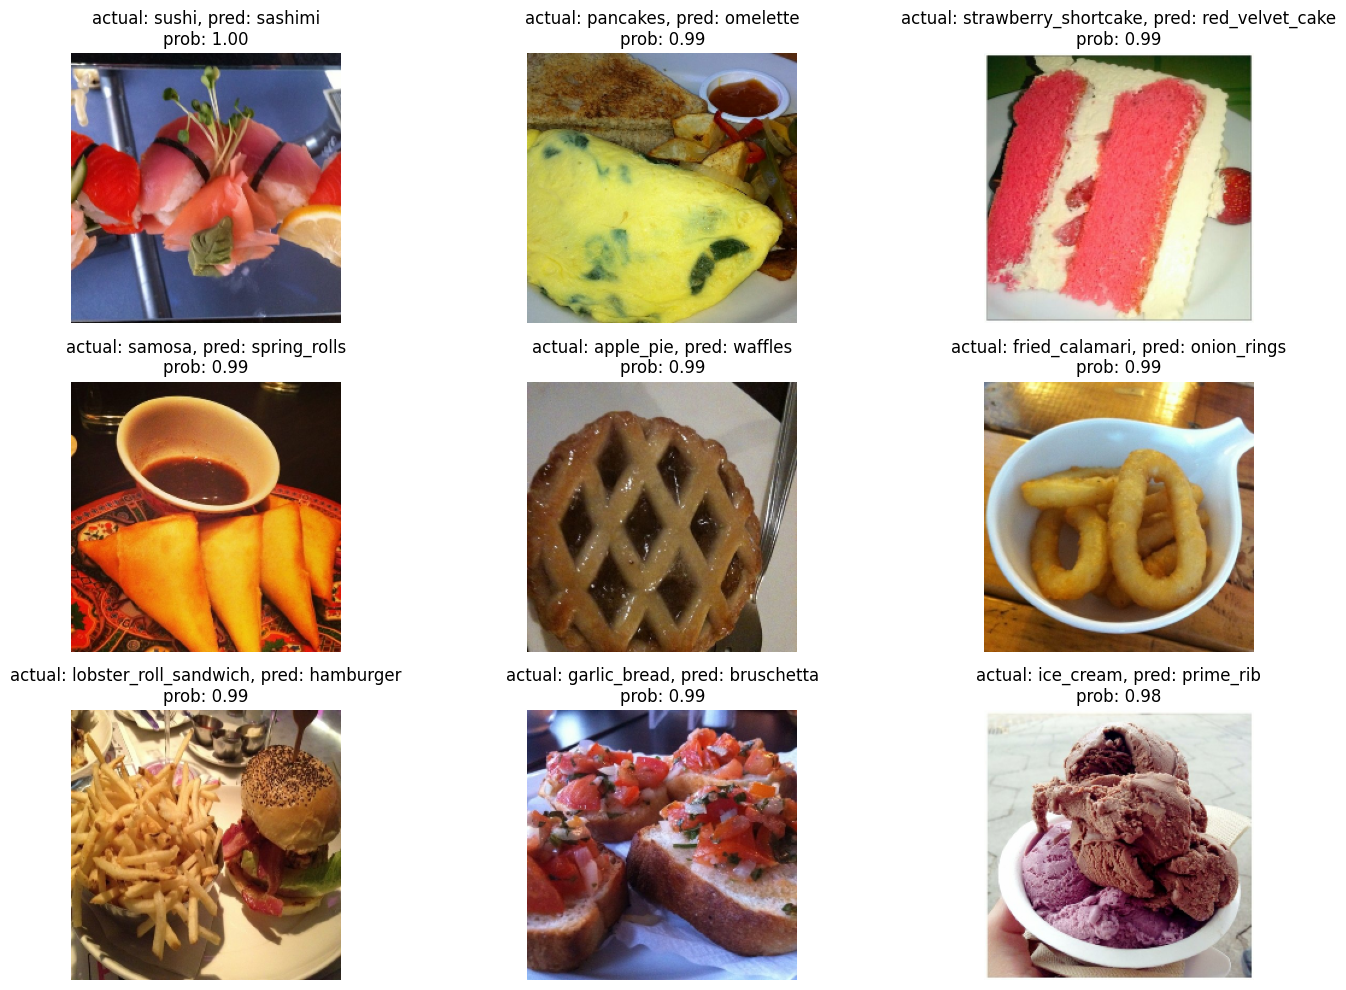

In [107]:
images_to_view = 9
start_index = 0

plt.figure(figsize=(15, 10))

for i, (index, row) in enumerate(top_100_wrong[start_index:start_index+images_to_view].iterrows()):
    plt.subplot(3, 3, i + 1)

    img_path = row["img_path"]

    if isinstance(img_path, bytes):
        img_path = img_path.decode("utf-8")

    img = load_and_prep_image(img_path, scale=False)

    pred_prob = row["pred_conf"]
    true_class_name = row["true_class_name"]
    pred_class_name = row["pred_class_name"]

    plt.imshow(img / 255.)
    plt.title(
        f"actual: {true_class_name}, pred: {pred_class_name}\nprob: {pred_prob:.2f}"
    )
    plt.axis(False)

plt.tight_layout()

In some images, model's predictions seems to better than actual :)  ⚓  

You can search for other wrong predictions by increasing start_index to 10 or another etc.  


## Test out our model on our own custom images

In [113]:
!wget -O custom_food_1.jpg "https://images.immediate.co.uk/production/volatile/sites/2/2025/11/Hasselback-TartifletteInsidepreview-641e56f-018382c.jpg?quality=90&resize=708,643"

!wget -O custom_food_2.jpg "https://healthnewshub.org/wp-content/uploads/2024/03/Fast-Food-Restaurants.jpg"

!wget -O custom_food_3.png "https://rdjohns.co.uk/wp-content/uploads/2023/07/65229744_l-copy.png"

--2026-05-28 19:45:11--  https://images.immediate.co.uk/production/volatile/sites/2/2025/11/Hasselback-TartifletteInsidepreview-641e56f-018382c.jpg?quality=90&resize=708,643
Resolving images.immediate.co.uk (images.immediate.co.uk)... 151.101.1.91, 151.101.65.91, 151.101.129.91, ...
Connecting to images.immediate.co.uk (images.immediate.co.uk)|151.101.1.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 241106 (235K) [image/jpeg]
Saving to: ‘custom_food_1.jpg’

custom_food_1.jpg   100%[===================>] 235.46K  --.-KB/s    in 0.01s   

2026-05-28 19:45:11 (22.3 MB/s) - ‘custom_food_1.jpg’ saved [241106/241106]

--2026-05-28 19:45:12--  https://healthnewshub.org/wp-content/uploads/2024/03/Fast-Food-Restaurants.jpg
Resolving healthnewshub.org (healthnewshub.org)... 18.217.18.131
Connecting to healthnewshub.org (healthnewshub.org)|18.217.18.131|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228630 (223K) [image/jpeg]
Saving to: ‘cu

In [114]:
custom_image_paths = [
    "custom_food_1.jpg",
    "custom_food_2.jpg",
    "custom_food_3.png"
]

In [115]:
def pred_and_plot_custom_images(model, image_paths, class_names, img_shape=224, top_k=5):
    plt.figure(figsize=(16, 5 * len(image_paths)))

    for idx, image_path in enumerate(image_paths):
        # Load image
        img = tf.keras.utils.load_img(image_path, target_size=(img_shape, img_shape))
        img_array = tf.keras.utils.img_to_array(img)

        # Expand dims for model: (224, 224, 3) -> (1, 224, 224, 3)
        img_expanded = tf.expand_dims(img_array, axis=0)

        # Predict
        pred_probs = model.predict(img_expanded, verbose=0)
        pred_index = np.argmax(pred_probs[0])
        pred_class = class_names[pred_index]
        pred_conf = pred_probs[0][pred_index]

        # Top-k predictions
        top_indices = pred_probs[0].argsort()[-top_k:][::-1]
        top_text = "\n".join([
            f"{class_names[i]}: {pred_probs[0][i]:.3f}"
            for i in top_indices
        ])

        # Plot image
        plt.subplot(len(image_paths), 2, idx * 2 + 1)
        plt.imshow(img_array / 255.)
        plt.axis(False)
        plt.title(
            f"Prediction: {pred_class}\nConfidence: {pred_conf:.3f}",
            fontsize=12
        )

        # Plot top-k text
        plt.subplot(len(image_paths), 2, idx * 2 + 2)
        plt.axis(False)
        plt.text(
            0.05,
            0.5,
            top_text,
            fontsize=13,
            va="center"
        )
        plt.title("Top predictions", fontsize=12)

    plt.tight_layout()
    plt.show()

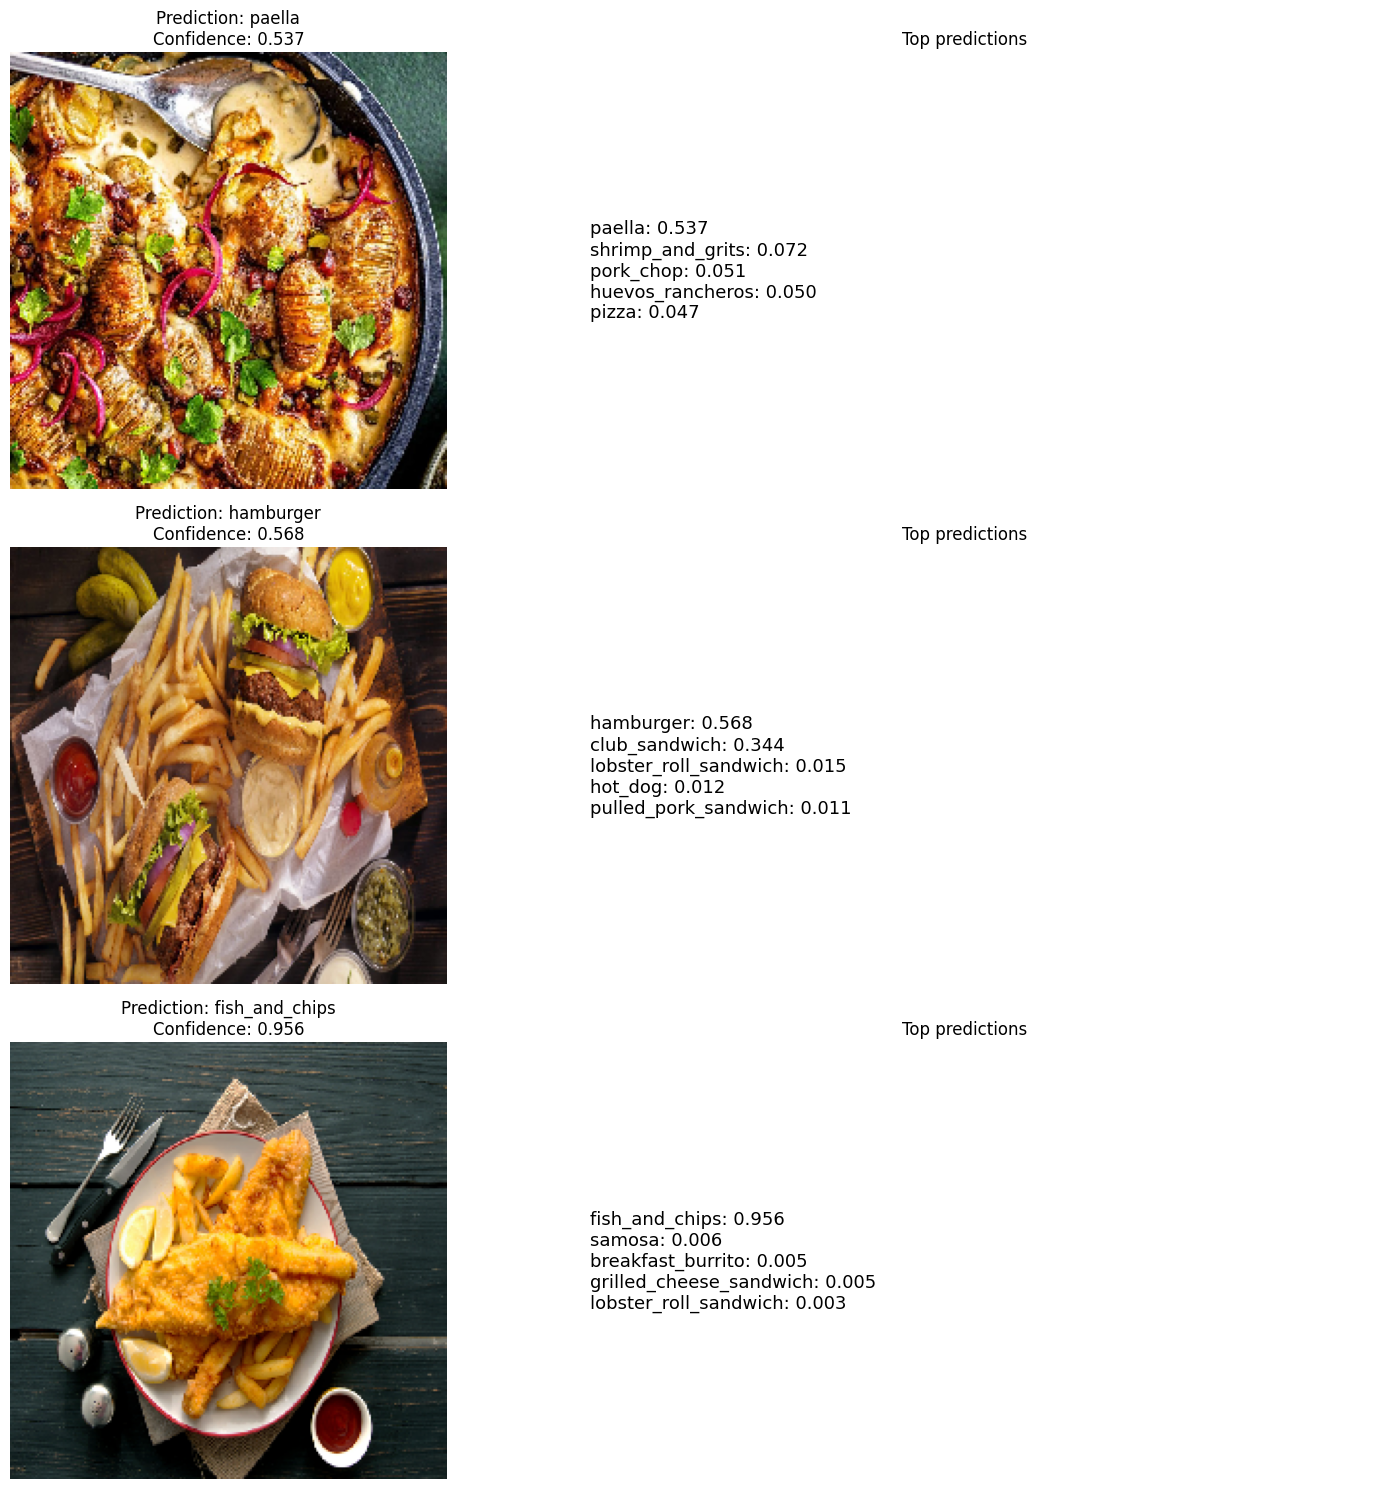

In [116]:
pred_and_plot_custom_images(
    model=loaded_model,
    image_paths=custom_image_paths,
    class_names=class_names,
    top_k=5
)

### Custom image test observations

The model performs well when the custom image clearly matches one of the Food101 classes, such as fish and chips. However, when multiple food items appear in the same image, such as hamburger with fries, the model may focus on the most dominant visual patterns. For foods that are not directly included in the Food101 label set, the model still assigns the image to the closest known class.